# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Sam Nieto Beltran]

**Date:** [9/10/26]

Dataset Head:


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


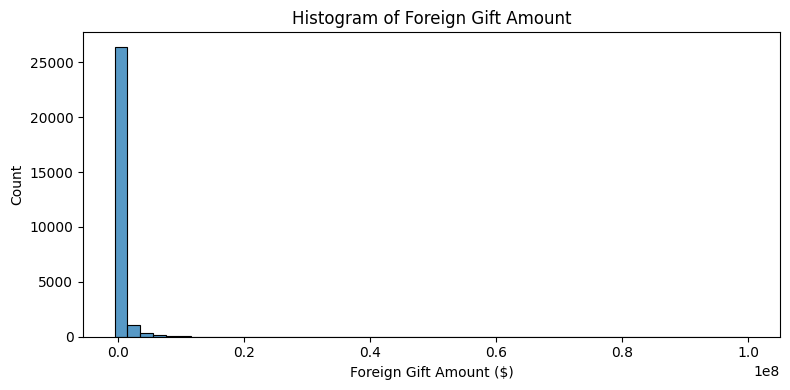

Summary Statistics for Foreign Gift Amount:
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

Gift Type Value Counts and Proportions:


,Count,Proportion
Gift Type,,
Contract,17274,0.612097
Monetary Gift,10936,0.387513
Real Estate,11,0.000390


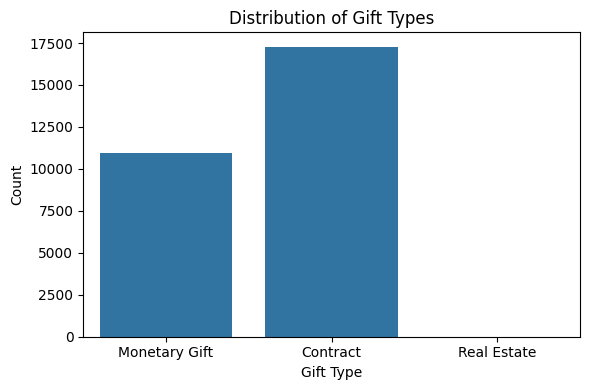

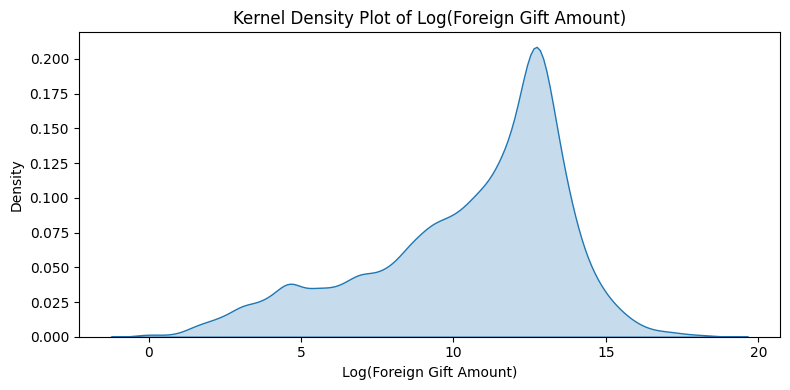

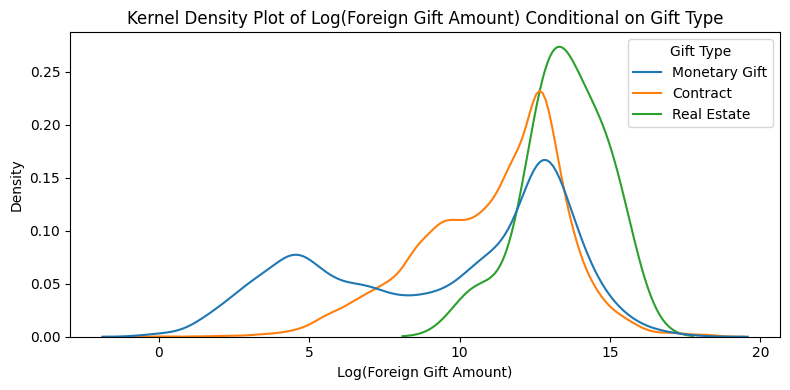


Top 15 Countries by Number of Gifts:


,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080



Top 15 Countries by Total Amount Given ($):


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445



Top Giftors Providing the Most Money (Total $):


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [1]:
# Your Phase 1 solution to the problem goes here.

# Question #1 was worked out on a piece of paper and is located in Github repo

# Question: 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. This loads the dataset
file_paths = ['./data/ForeignGifts_edu.csv', 'ForeignGifts_edu.csv']
file_to_load = next((p for p in file_paths if os.path.exists(p)), None)

if file_to_load:
    df = pd.read_csv(file_to_load)
else:
    url = "https://raw.githubusercontent.com/samnietobeltran-jpg/A02-eda-and-visualization/main/data/ForeignGifts_edu.csv"
    df = pd.read_csv(url)

print("Dataset Head:")
display(df.head())

# This code automatically scans the column headers to find and store the names of the amount, type, country, and donor columns
amount_col = [c for c in df.columns if 'amount' in c.lower() or 'value' in c.lower()][0]
gift_type_col = [c for c in df.columns if 'type' in c.lower()][0]
country_col = [c for c in df.columns if 'country' in c.lower()][0]
giftor_col = [c for c in df.columns if 'giftor' in c.lower() or 'donor' in c.lower() or 'entity' in c.lower()][0]


# 2. Foreign Gift Amount: Histogram & Description
plt.figure(figsize=(8, 4))
sns.histplot(df[amount_col].dropna(), bins=50, kde=False)
plt.title('Histogram of Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Summary Statistics for Foreign Gift Amount:")
print(df[amount_col].describe())

# COMMENTS / FINDINGS FOR Q2:
# Findings Description:
# The distribution is extremely right-skewed. A vast majority of foreign gifts are small to moderate in value.


# 3. Gift Type: Value Counts & Proportions
gift_counts = df[gift_type_col].value_counts(dropna=False)
gift_proportions = df[gift_type_col].value_counts(normalize=True, dropna=False)

gift_table = pd.DataFrame({'Count': gift_counts, 'Proportion': gift_proportions})
print("\nGift Type Value Counts and Proportions:")
display(gift_table)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=gift_type_col)
plt.title('Distribution of Gift Types')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# FINDINGS FOR Q3:
# Contracts make up the majority of foreign transfers at approximately 61.21% (17,274 gifts).
# followed by Monetary Gifts at approximately 38.75% (10,936 gifts).
# Real Estate represents a very small portion, being about 0.04%

# 4. Log of Foreign Gift Amount: KDE & Conditional KDE
df_valid = df[df[amount_col] > 0].copy()
df_valid['log_amount'] = np.log(df_valid[amount_col])

# Overall KDE Plot
plt.figure(figsize=(8, 4))
sns.kdeplot(df_valid['log_amount'], fill=True)
plt.title('Kernel Density Plot of Log(Foreign Gift Amount)')
plt.xlabel('Log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# Conditional KDE Plot by Gift Type
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_valid, x='log_amount', hue=gift_type_col, common_norm=False)
plt.title('Kernel Density Plot of Log(Foreign Gift Amount) Conditional on Gift Type')
plt.xlabel('Log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# COMMENTS / PATTERNS FOR Q4:
# Patterns: the heavily skewed raw data, reveals a bell-shaped distribution. Comparing across gift types shows that
# contracts tend to have a higher median/mean log value compared to monetary gifts.


# 5. Top 15 Countries (Number of Gifts vs. Total Amount)
# 15 Countries Number of Gifts: ENGLAND, AUSTRALIA, CANADA, JAPAN, SWITZERLAND, SAUDI ARABIA, FRANCE, GERMANY, HONG KONG, SOUTH KOREA, QATAR, THE NETHERLANDS, KOREA, INDIA, TAIWAN
# 15 countries total amount: QATAR, ENGLAND, CHINA, SAUDI ARABIA, BERMUDA, CANADA, HONG KONG, JAPAN, SWITZERLAND, INDIA, GERMANY, UNITED ARAB EMIRATES, FRANCE, SINGAPORE, AUSTRALIA
top_15_count = df.groupby(country_col).size().nlargest(15)
print(f"\nTop 15 Countries by Number of Gifts:")
display(top_15_count)

top_15_amount = df.groupby(country_col)[amount_col].sum().nlargest(15)
print(f"\nTop 15 Countries by Total Amount Given ($):")
display(top_15_amount)


# 6. Top Giftors by Total Amount Given
# Giftors with most money given: QATAR, ENGLAND, CHINA, SAUDI ARABIA, BERMUDA, CANADA, HONG KONG, JAPAN, SWITZERLAND, INDIA, GERMANY, UNITED ARAB EMIRATES, FRANCE, SINGAPORE, AUSTRALIA
top_giftors = df.groupby(giftor_col)[amount_col].sum().nlargest(15)
print("\nTop Giftors Providing the Most Money (Total $):")
display(top_giftors)

In [10]:
!git clone https://github.com/samnietobeltran-jpg/A02-eda-and-visualization.git
%cd A02-eda-and-visualization


Cloning into 'A02-eda-and-visualization'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 6 (from 1)
Receiving objects: 100% (10/10), 1.19 MiB | 9.94 MiB/s, done.
/content/A02-eda-and-visualization/A02-eda-and-visualization


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]